1. N = 20 (Кол-во точек)
2. [a,b] (интервал) = 
3. p (длина окна) = 4 (исходное)  
4. x(t) = ln 1 - 1

Эпоха 0: Суммарная кв. ошибка = 0.012684
Эпоха 500: Суммарная кв. ошибка = 0.000021
Эпоха 1000: Суммарная кв. ошибка = 0.000021
Эпоха 1500: Суммарная кв. ошибка = 0.000020
Эпоха 2000: Суммарная кв. ошибка = 0.000020
Эпоха 2500: Суммарная кв. ошибка = 0.000019
Эпоха 3000: Суммарная кв. ошибка = 0.000019
Эпоха 3500: Суммарная кв. ошибка = 0.000019
Эпоха 4000: Суммарная кв. ошибка = 0.000018
Эпоха 4500: Суммарная кв. ошибка = 0.000018
Эпоха 5000: Суммарная кв. ошибка = 0.000018
Эпоха 5500: Суммарная кв. ошибка = 0.000018
Эпоха 6000: Суммарная кв. ошибка = 0.000017
Эпоха 6500: Суммарная кв. ошибка = 0.000017
Эпоха 7000: Суммарная кв. ошибка = 0.000017
Эпоха 7500: Суммарная кв. ошибка = 0.000016
Эпоха 8000: Суммарная кв. ошибка = 0.000016
Эпоха 8500: Суммарная кв. ошибка = 0.000016
1 Скорость обучения
9000 Количество итераций обучения


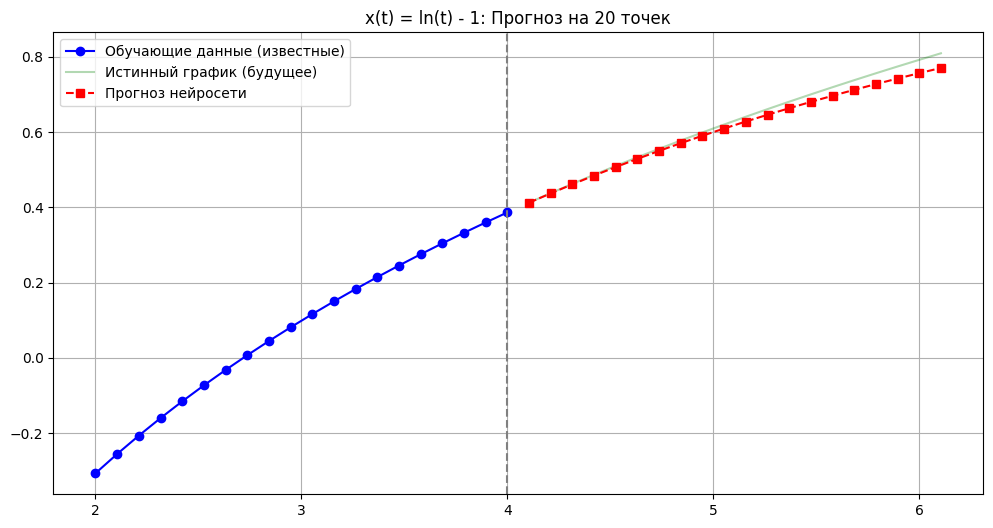

In [29]:
import numpy as np
import matplotlib.pyplot as plt

class Perceptron:
    def __init__(self, weights):
        self.w = weights

    def net(self, x):
        return sum(xi * wi for xi, wi in zip(x, self.w))

    def update_weights_threshold(self, x, err, lr):
        for i in range(len(self.w)):
            self.w[i] += lr * err * x[i]

a = 2                  # Начало интервала 
b = 4                  # Конец интервала обучения 
N = 20                 # Количество точек 
p = 6                  # Размер скользящего окна 
lr = 1           
MAX_EPOCHS =  9000

def target_function(t): 
    return np.log(t) - 1

t_steps = np.linspace(a, b, N)
x_values = target_function(t_steps)

# Вычисляем шаг времени 
time_step = t_steps[1] - t_steps[0]

# Подготовка обучающих пар (Вход - Выход) методом скользящего окна
training_inputs = []
training_targets = []

for i in range(len(x_values) - p):
    current_window = list(x_values[i : i + p]) + [1.0]
    training_inputs.append(current_window)
    
    training_targets.append(x_values[i + p])

# Весов должно быть на 1 больше, чем размер окна (из-за смещения)
np.random.seed(42)
initial_weights = np.random.uniform(0, 0, p + 1).tolist()
model = Perceptron(initial_weights)

for epoch in range(MAX_EPOCHS):
    total_error_sq = 0
    for x_input, y_true in zip(training_inputs, training_targets):
        y_pred = model.net(x_input)
        error = y_true - y_pred
        total_error_sq += error**2
        
        model.update_weights_threshold(x_input, error, lr)
    
    # Выводим прогресс каждые 500 эпох
    if epoch % 500 == 0:
        print(f"Эпоха {epoch}: Суммарная кв. ошибка = {total_error_sq:.6f}")

# Берем последние известные данные из обучения, чтобы начать прогноз
prediction_window = list(x_values[-p:])
predicted_results = []


for _ in range(N):
    
    model_input = prediction_window + [1.001]
    
    next_val = model.net(model_input)
    predicted_results.append(next_val)

    prediction_window.pop(0)
    prediction_window.append(next_val)

t_prediction = np.array([b + (i+1)*time_step for i in range(N)])
x_true_future = target_function(t_prediction)
print(lr, "Скорость обучения")
print(MAX_EPOCHS, "Количество итераций обучения")
plt.figure(figsize=(12, 6))
plt.plot(t_steps, x_values, 'bo-', label='Обучающие данные (известные)')
plt.plot(t_prediction, x_true_future, 'g-', alpha=0.3, label='Истинный график (будущее)')
plt.plot(t_prediction, predicted_results, 'rs--', label='Прогноз нейросети')

plt.axvline(x=b, color='gray', linestyle='--')
plt.title(f'x(t) = ln(t) - 1: Прогноз на {N} точек')
plt.legend()
plt.grid(True)
plt.show()
